In [1]:
import matplotlib.pyplot as plt
from goes2go.data import goes_nearesttime
from datetime import datetime
import warnings as warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
import os
import cartopy as ccrs
import cartopy.feature as cfeature
# Specify working directory with raw string and change with os
working_file_path = os.path.abspath(r'C:\Users\308ca\Desktop\HerbieEarthaccess\Goes-2-TornadoProj-41926')
os.chdir(working_file_path)
print("Current Working Directory:", os.getcwd())  

Current Working Directory: C:\Users\308ca\Desktop\HerbieEarthaccess\Goes-2-TornadoProj-41926


https://goes2go.readthedocs.io/en/latest/user_guide/notebooks/DEMO_rgb_recipes.html#
https://goes2go.readthedocs.io/en/latest/reference_guide/index.html#rgb-recipes

 👮🏻‍♂️ File already exists. Do not overwrite: C:\Users\308ca\data\noaa-goes19\ABI-L2-MCMIPC\2026\106\00\OR_ABI-L2-MCMIPC-M6_G19_s20261060001172_e20261060003545_c20261060004231.nc
📦 Finished downloading [1] files to [C:\Users\308ca\data\noaa-goes19\ABI-L2-MCMIPC].
📖💽 Reading (1/1) file from LOCAL COPY [C:\Users\308ca\data\noaa-goes19\ABI-L2-MCMIPC\2026\106\00\OR_ABI-L2-MCMIPC-M6_G19_s20261060001172_e20261060003545_c20261060004231.nc]. 

C:\Users\308ca\anaconda3\envs\herbie_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📚 Finished reading [1] files into xarray.Dataset.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      


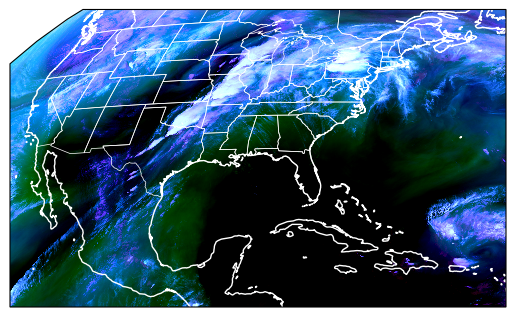

In [2]:
# Single satellite imagery extraction
# 8:00 PM ET on April 15 is 00:00:00 UTC on April 16
# datetime(year, month, day, hour, minute, second)
target_time = datetime(2026, 4, 16, 0, 0, 0)
g = goes_nearesttime(target_time, satellite='goes19', product='ABI', return_as='xarray')

ax = plt.subplot(projection=g.rgb.crs )
# **g.rgb.imshow_kwargs ensures borders and coastlines and imagery align correctly
# ** takes georeferencing dictionary as keyword arguments so dont need to type out:
#      extent = map pixel location to coordinates, origin = correct map orientation
ax.imshow(g.rgb.WaterVapor(), **g.rgb.imshow_kwargs)
ax.coastlines(color='white', linewidth=1)
#ax.add_feature(cfeature.BORDERS, edgecolor='red', linewidth=1) # National
ax.add_feature(cfeature.STATES, edgecolor='white', linewidth=0.5) # State Borders

# save image after displaying it
plt.savefig('4152026-8PMET-WaterVapor-CONUS.png', dpi=300, bbox_inches='tight')

print(f"Your image is saved at: {os.path.join(os.getcwd(), '4152026-8PMET-TrueColor-CONUS-Clouds.png')}")